# Introduction

The banking industry widely uses direct marketing campaigns to promote financial products such as term deposits. However, the success rate of these campaigns is typically low, leading to inefficient use of resources and increased operational costs. Identifying customers who are more likely to subscribe can significantly improve marketing effectiveness.

With the availability of structured customer-level data, statistical and machine learning techniques can be applied to analyze behavioral patterns and predict subscription outcomes. By examining demographic characteristics, financial indicators, and previous marketing interactions, we can better understand the factors influencing customer decisions.

In this project, we analyze the Bank Marketing dataset to study term deposit subscription behavior and apply classification models to evaluate predictive performance.

# Objective

The primary objective of this project is to examine how customer demographics, financial attributes, and campaign-related variables influence the likelihood of subscribing to a term deposit.

**Specifically, this project aims to:**

*   Identify key predictors associated with subscription behavior

*   Quantify the impact of significant variables

*   Build classification models to predict customer subscription

*   Evaluate model performance using appropriate metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC

**The central research question is:**

**Which factors most significantly affect term deposit subscription, and how accurately can subscription behavior be predicted using statistical methods?**

# Dataset

**Data Source:** UCI Machine Learning Repository - Bank Marketing Dataset
https://archive.ics.uci.edu/dataset/222/bank+marketing

The dataset contains information collected from direct telemarketing campaigns conducted by a Portuguese banking institution between 2008 and 2010.

**Key characteristics of the dataset:**

45,211 observations

16 predictor variables

1 binary response variable (y) indicating whether the customer subscribed to a term deposit

**The variables include:**

**Demographic features:** age, job, marital status, education

**Financial features:** account balance, housing loan, personal loan, default status

**Campaign features:** contact type, duration, number of contacts, previous campaign outcome

The dataset contains both numerical and categorical variables, requiring preprocessing steps such as encoding categorical variables and scaling numerical features prior to modeling.

##SETTING UP

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df= pd.read_csv('bank-additional-full.csv',sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.shape

(41188, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

##Preprocessing pipeline for dataset

- Categorical Data: one hot encoder
- Numerical Data: standardize
- Convert target variable y to binary
- Remove duration feature as not known before marketing campaign, hence including would lead to data leakage


Categorical Features:job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome

Numerical Features: age, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed



In [7]:
#dropping column duration
df = df.drop('duration', axis=1)

In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:
df['y']= df['y']=="yes"
df_orig= df.copy()
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False


In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# Exclude 'y' if it's still in object dtype, though it should be int/bool now
if 'y' in categorical_cols:
    categorical_cols.remove('y')

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df = df_encoded
df.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False


In [11]:
df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [12]:
df['pdays'].unique()


array([999,   6,   4,   3,   5,   1,   0,  10,   7,   8,   9,  11,   2,
        12,  13,  14,  15,  16,  21,  17,  18,  22,  25,  26,  19,  27,
        20])

pdays has a unique value of 999 for customers never contacted before, to deal with this, we're making a separate binary column 'contacted_before' with 1/0 values and replacing the 999 values with the mean of that column

In [13]:
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)
mean_pdays = df.loc[df['pdays'] != 999, 'pdays'].mean()
df['pdays_scaled'] = df['pdays'].replace(999, mean_pdays)
df.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,was_contacted_before,pdays_scaled
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,False,False,True,False,False,False,True,False,0,6.014521
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,False,False,True,False,False,False,True,False,0,6.014521
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,False,False,True,False,False,False,True,False,0,6.014521
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,False,False,True,False,False,False,True,False,0,6.014521
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,False,False,True,False,False,False,True,False,0,6.014521


In [14]:
df = df.drop(columns=['pdays'])
df.head()

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_blue-collar,...,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,was_contacted_before,pdays_scaled
0,56,1,0,1.1,93.994,-36.4,4.857,5191.0,False,False,...,False,False,True,False,False,False,True,False,0,6.014521
1,57,1,0,1.1,93.994,-36.4,4.857,5191.0,False,False,...,False,False,True,False,False,False,True,False,0,6.014521
2,37,1,0,1.1,93.994,-36.4,4.857,5191.0,False,False,...,False,False,True,False,False,False,True,False,0,6.014521
3,40,1,0,1.1,93.994,-36.4,4.857,5191.0,False,False,...,False,False,True,False,False,False,True,False,0,6.014521
4,56,1,0,1.1,93.994,-36.4,4.857,5191.0,False,False,...,False,False,True,False,False,False,True,False,0,6.014521


In [15]:
from sklearn.preprocessing import StandardScaler

#scaling numeric features
numeric_cols = ['age', 'campaign', 'previous',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                'euribor3m', 'nr.employed', 'pdays_scaled']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [16]:
df.head()

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_blue-collar,...,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,was_contacted_before,pdays_scaled
0,1.533034,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,False,False,...,False,False,True,False,False,False,True,False,0,-2.422322e-15
1,1.628993,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,False,False,...,False,False,True,False,False,False,True,False,0,-2.422322e-15
2,-0.290186,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,False,False,...,False,False,True,False,False,False,True,False,0,-2.422322e-15
3,-0.002309,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,False,False,...,False,False,True,False,False,False,True,False,0,-2.422322e-15
4,1.533034,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,False,False,...,False,False,True,False,False,False,True,False,0,-2.422322e-15


In [17]:
df.describe()

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,pdays_scaled
count,4.118800e+04,4.118800e+04,4.118800e+04,4.118800e+04,4.118800e+04,4.118800e+04,41188.000000,4.118800e+04,41188.000000,4.118800e+04
mean,-1.880382e-16,-7.590531e-17,5.520386e-18,7.797546e-17,-3.315820e-14,-1.352495e-16,0.000000,-1.024860e-14,0.036783,-2.433283e-15
std,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012,1.000012e+00,0.188230,1.000012e+00
min,-2.209365e+00,-5.659220e-01,-3.494943e-01,-2.216433e+00,-2.374889e+00,-2.224953e+00,-1.722351,-2.815697e+00,0.000000,-8.201678e+00
25%,-7.699804e-01,-5.659220e-01,-3.494943e-01,-1.197935e+00,-8.649547e-01,-4.747909e-01,-1.312994,-9.402810e-01,0.000000,-2.422322e-15
50%,-1.942267e-01,-2.049085e-01,-3.494943e-01,6.480923e-01,2.994571e-01,-2.803284e-01,0.712460,3.316799e-01,0.000000,-2.422322e-15
75%,6.694038e-01,1.561049e-01,-3.494943e-01,8.390606e-01,7.227225e-01,8.864466e-01,0.772422,8.451701e-01,0.000000,-2.422322e-15
max,5.563310e+00,1.928982e+01,1.379492e+01,8.390606e-01,2.058168e+00,2.939106e+00,0.820853,8.451701e-01,1.000000,2.861676e+01


In [18]:
# saving the preprocessed data for modelling:
df_modelling = df.copy()
df_modelling.head()

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_blue-collar,...,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,was_contacted_before,pdays_scaled
0,1.533034,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,False,False,...,False,False,True,False,False,False,True,False,0,-2.422322e-15
1,1.628993,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,False,False,...,False,False,True,False,False,False,True,False,0,-2.422322e-15
2,-0.290186,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,False,False,...,False,False,True,False,False,False,True,False,0,-2.422322e-15
3,-0.002309,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,False,False,...,False,False,True,False,False,False,True,False,0,-2.422322e-15
4,1.533034,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,False,False,...,False,False,True,False,False,False,True,False,0,-2.422322e-15


##EDA

<Axes: xlabel='y', ylabel='count'>

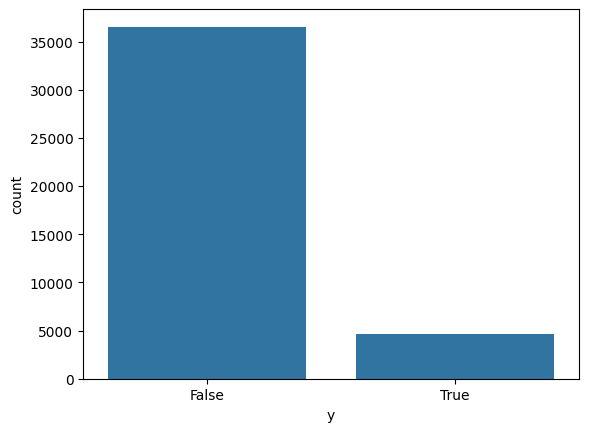

In [20]:
import seaborn as sns
sns.countplot(x='y', data=df)

Class Imbalance clear from graph

<Axes: >

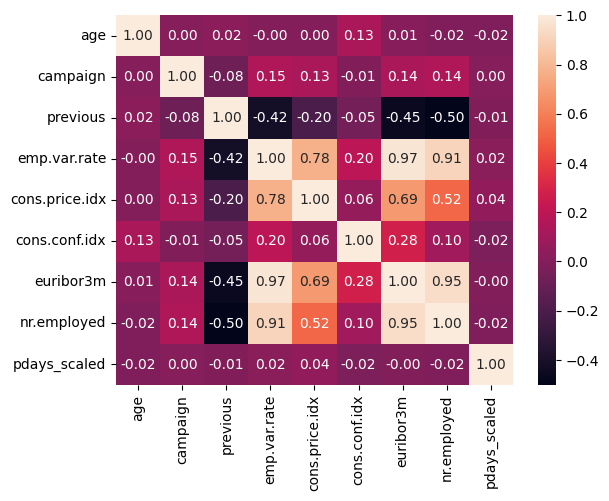

In [21]:
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f")

In [22]:
days_order = ['mon', 'tue', 'wed', 'thu', 'fri']

# Convert to ordered categorical
df_orig['day_of_week'] = pd.Categorical(df_orig['day_of_week'],
                                        categories=days_order,
                                        ordered=True)

months_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul',
                'aug', 'sep', 'oct', 'nov', 'dec']

df_orig['month'] = pd.Categorical(df_orig['month'],
                                  categories=months_order,
                                  ordered=True)

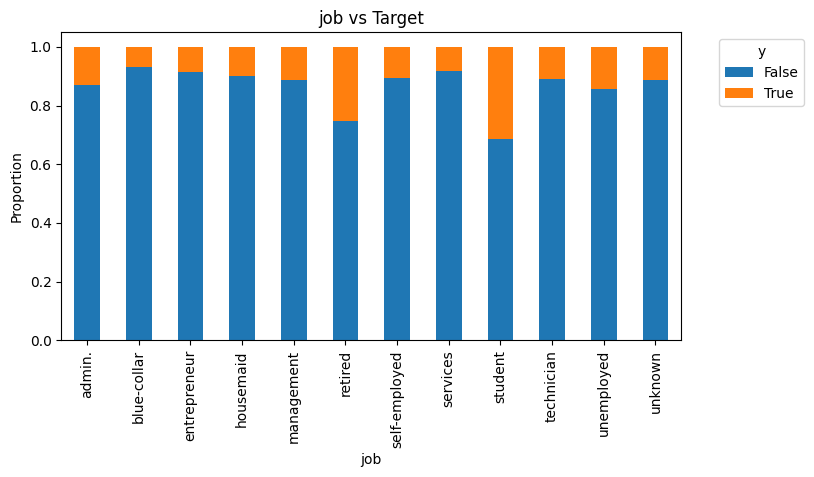

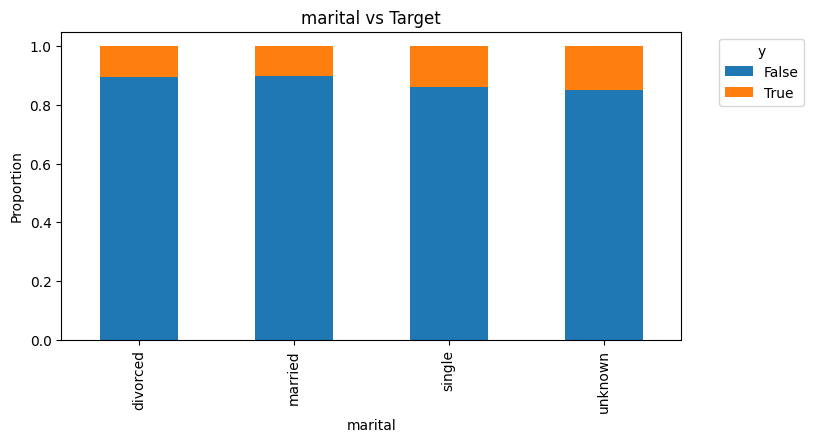

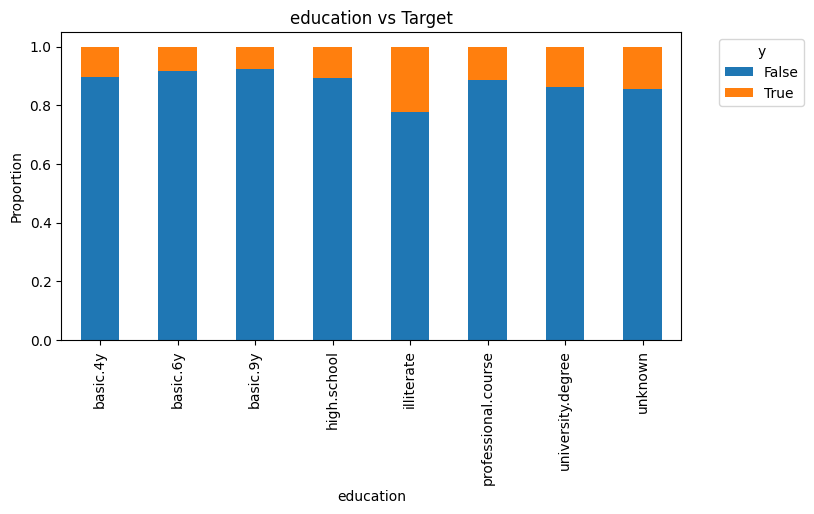

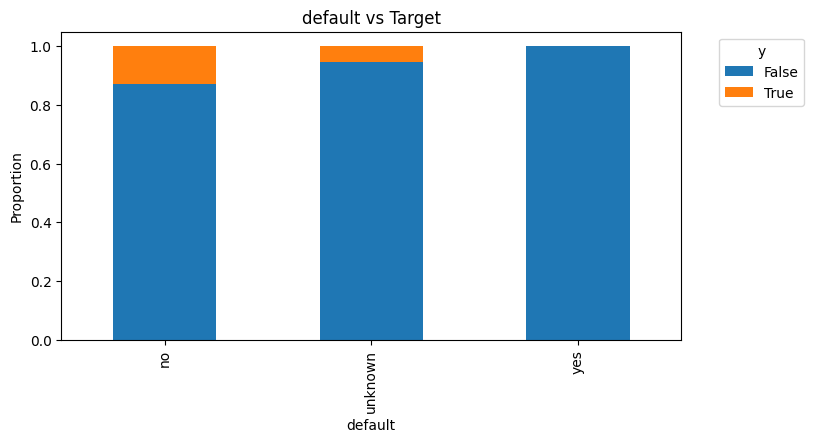

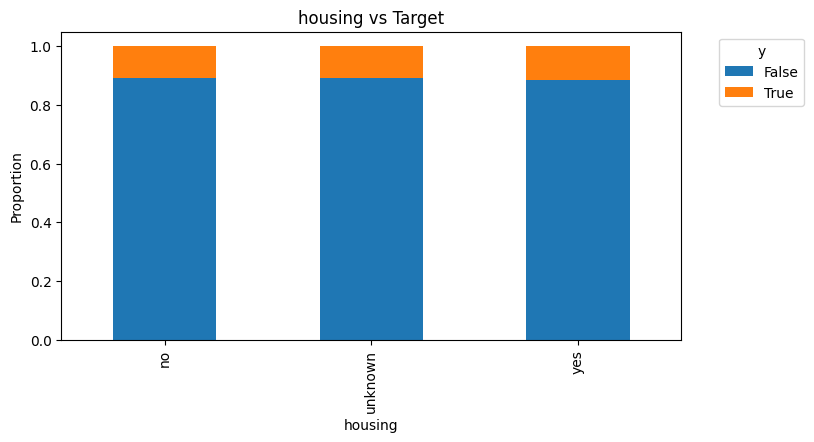

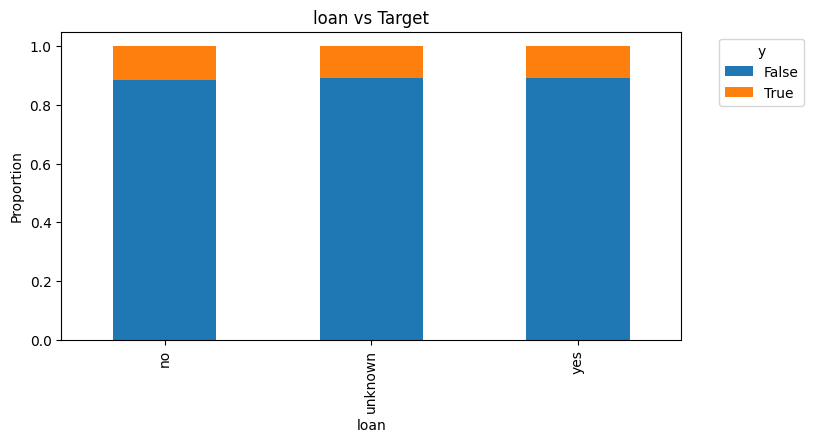

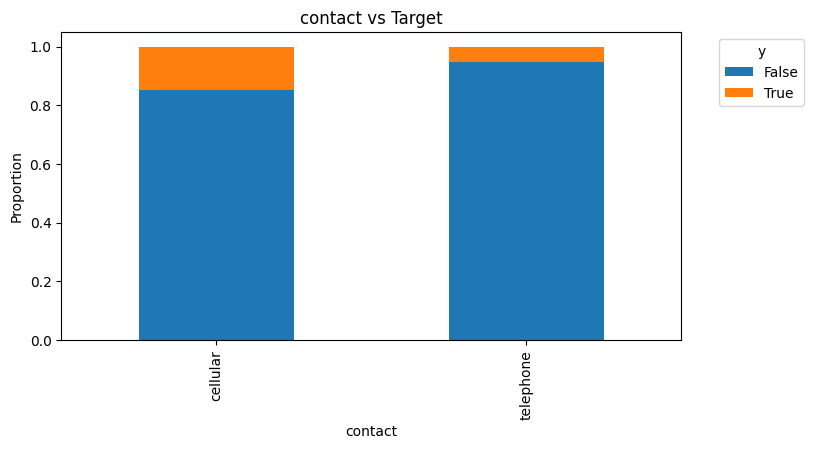

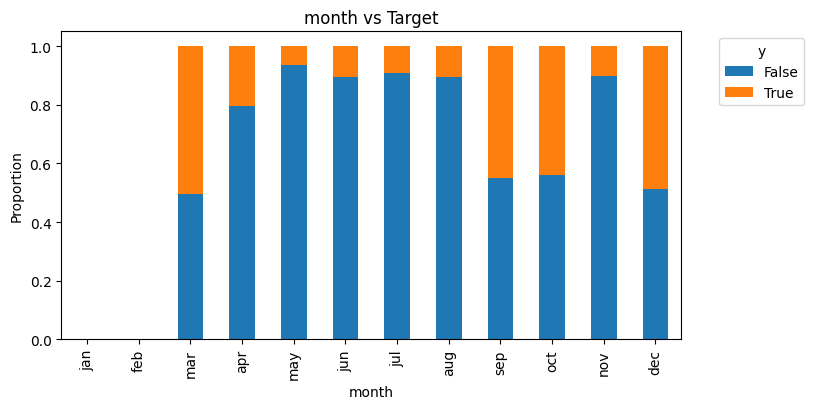

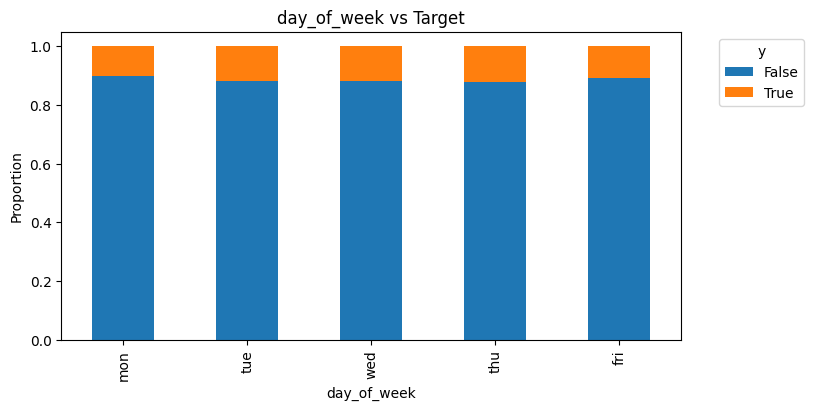

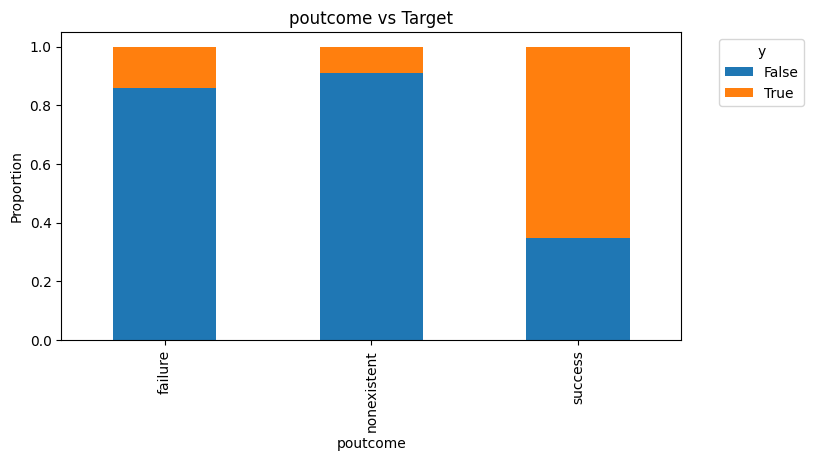

In [23]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

for col in cat_cols:
    counts = df_orig.groupby([col, 'y']).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0)  # normalize per category

    proportions.plot(kind='bar', stacked=True, figsize=(8,4))
    plt.title(f'{col} vs Target')
    plt.ylabel('Proportion')
    plt.legend(title='y', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

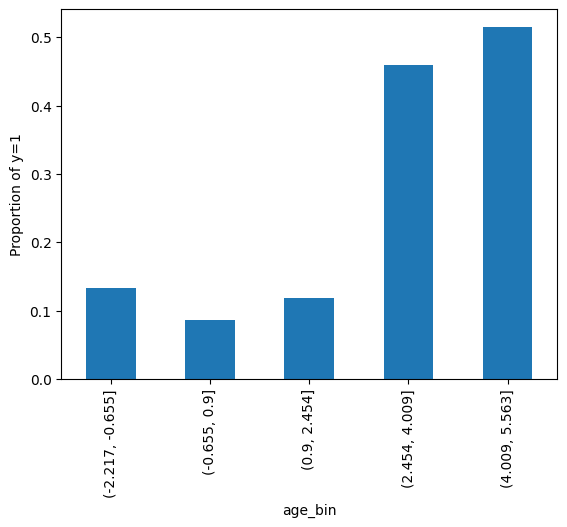

In [24]:
df['age_bin'] = pd.cut(df['age'], bins=5)
age_rates = df.groupby('age_bin')['y'].mean()
age_rates.plot(kind='bar')
plt.ylabel('Proportion of y=1')
plt.show()

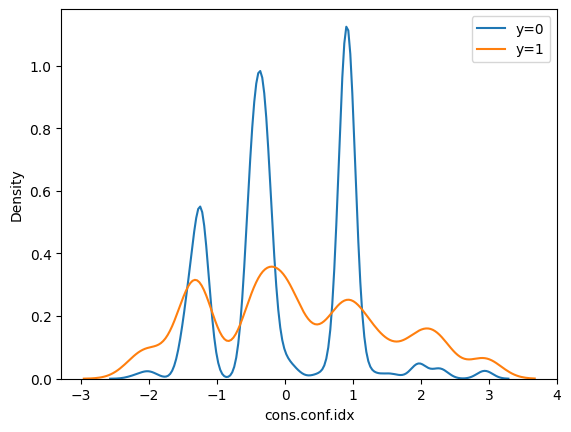

In [25]:
import seaborn as sns
sns.kdeplot(df[df['y']==0]['cons.conf.idx'], label='y=0')
sns.kdeplot(df[df['y']==1]['cons.conf.idx'], label='y=1')
plt.legend()
plt.show()

##mulicolinearity check

In [ ]:
# multicoliearity check:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df_modelling.drop('y', axis=1)
vif_data = pd.DataFrame()
X_numeric = X.copy()


#extarct numerical columns:
X_numeric = X_numeric.select_dtypes(include=[np.number])

X_numeric.columns.tolist()


['age',
 'campaign',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'was_contacted_before',
 'pdays_scaled']

In [ ]:
vif_data['feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.values, i) for i in range(len(X_numeric.columns))]

vif_data = vif_data.sort_values(by='VIF', ascending=False)
vif_data.head(10)


,feature,VIF
6,euribor3m,64.361137
3,emp.var.rate,33.199035
7,nr.employed,31.707053
4,cons.price.idx,6.337664
5,cons.conf.idx,2.648099
2,previous,1.771378
8,was_contacted_before,1.577055
1,campaign,1.033689
0,age,1.019159
9,pdays_scaled,1.010606


In [ ]:
print("Features with VIF > 10 (potential multicollinearity):")
high_vif_features = vif_data[vif_data['VIF'] > 5]
print(high_vif_features)


Features with VIF > 10 (potential multicollinearity):
          feature        VIF
6       euribor3m  64.361137
3    emp.var.rate  33.199035
7     nr.employed  31.707053
4  cons.price.idx   6.337664


In [ ]:
# removing higly collinear variables:
Features  = df_modelling.drop('y', axis=1)
X = Features.drop(columns=[
    'nr.employed',
    'euribor3m',
    'emp.var.rate',
    'cons.price.idx'
])
y = df_modelling['y']

## setting up train and test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## LOGISTIC REGRESSION

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define the parameter grid
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# 2. Initialize a LogisticRegression model
log_reg = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000, class_weight='balanced')

# 3. Initialize a GridSearchCV object
grid_search_log_reg = GridSearchCV(estimator=log_reg, param_grid=param_grid_log_reg, cv=5, scoring='accuracy', n_jobs=-1)


In [ ]:
grid_search_log_reg.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, random_state=42,
                                          solver='liblinear'),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2']},
             scoring='accuracy')

In [ ]:
print("Best parameters found: ", grid_search_log_reg.best_params_)
print("Best accuracy found: ", grid_search_log_reg.best_score_)

Best parameters found:  {'C': 0.001, 'penalty': 'l1'}
Best accuracy found:  0.8232473444613049


In [ ]:
best_log_reg = grid_search_log_reg.best_estimator_
y_pred = best_log_reg.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.8248
Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.89      0.90      7310
        True       0.26      0.31      0.29       928

    accuracy                           0.82      8238
   macro avg       0.59      0.60      0.59      8238
weighted avg       0.84      0.82      0.83      8238

Confusion Matrix:
[[6507  803]
 [ 640  288]]


## Random Forest Classification



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

print("Random Forest parameter grid defined successfully.")

Random Forest parameter grid defined successfully.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Initialize a RandomForestClassifier model with class_weight='balanced'
rf_classifier = RandomForestClassifier(class_weight='balanced', random_state=42)

# Initialize a GridSearchCV object for Random Forest
grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)

print("GridSearchCV object for Random Forest initialized successfully.")

GridSearchCV object for Random Forest initialized successfully.


In [ ]:
grid_search_rf.fit(X_train, y_train)

GridSearchCV for Random Forest fitted successfully.


In [ ]:
print("Best parameters found: ", grid_search_rf.best_params_)
print("Best accuracy found: ", grid_search_rf.best_score_)

Best parameters found:  {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 300}
Best accuracy found:  0.8893778452200303


In [ ]:
best_rf_classifier = grid_search_rf.best_estimator_
y_pred_rf = best_rf_classifier.predict(X_test)
print("Predictions on X_test made successfully.")

Predictions on X_test made successfully.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Random Forest Classification Report:")
print(report_rf)
print("Random Forest Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Accuracy: 0.8918
Random Forest Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.97      0.94      7310
        True       0.54      0.26      0.35       928

    accuracy                           0.89      8238
   macro avg       0.73      0.62      0.65      8238
weighted avg       0.87      0.89      0.87      8238

Random Forest Confusion Matrix:
[[7107  203]
 [ 688  240]]


# SUMARY - model, hyperparameter tuning, and performance

### Logistic regression



#### Hyperparameter Tuning
You used `GridSearchCV` to find the best hyperparameters for your Logistic Regression model. The parameters tuned were:

*   `C`: This is the inverse of regularization strength. Smaller values specify stronger regularization.
*   `penalty`: This specifies the type of regularization ('l1' for Lasso or 'l2' for Ridge).

The `GridSearchCV` found the `best_params_` to be `{'C': 0.001, 'penalty': 'l1'}`. This means that a relatively strong L1 regularization was chosen, which can help in feature selection by shrinking some coefficients to zero.

#### Best Cross-Validation Accuracy

The `best_accuracy_found` during cross-validation was `0.8232`. This indicates the average accuracy achieved by the best model on the training data across the 5 folds of cross-validation.

#### Model Performance on Test Set

After training the model with the best parameters, you evaluated its performance on the unseen test set:

*   **Accuracy:** `0.8248`. This is the overall proportion of correctly classified instances. While it seems high, it's important to consider the class imbalance.

*   **Classification Report:**
    *   **Class False (No Subscription):**
        *   `Precision: 0.91`: Out of all instances predicted as 'False', 91% were actually 'False'.
        *   `Recall: 0.89`: Out of all actual 'False' instances, 89% were correctly identified.
        *   `F1-score: 0.90`
    *   **Class True (Subscription):**
        *   `Precision: 0.26`: This is quite low. Out of all instances predicted as 'True' (customer will subscribe), only 26% actually did subscribe.
        *   `Recall: 0.31`: Also low. Out of all actual 'True' instances, only 31% were correctly identified by the model.
        *   `F1-score: 0.29`
    *   **Macro Avg:** Averages precision, recall, and f1-score for both classes without considering class imbalance. The values are low (`0.59-0.60`), indicating poor performance on the minority class.
    *   **Weighted Avg:** Averages precision, recall, and f1-score for both classes considering class imbalance. These values (`0.84`, `0.82`, `0.83`) are closer to the overall accuracy because the majority class dominates.

*   **Confusion Matrix:**
    `[[6507, 803], [640, 288]]`
    *   **True Negatives (TN):** 6507 (Correctly predicted 'False')
    *   **False Positives (FP):** 803 (Incorrectly predicted 'True' when it was 'False' - Type I error)
    *   **False Negatives (FN):** 640 (Incorrectly predicted 'False' when it was 'True' - Type II error)
    *   **True Positives (TP):** 288 (Correctly predicted 'True')

### Conclusion on Performance

The model shows a high overall accuracy, but this is largely due to the high number of correctly classified 'False' instances (customers who did not subscribe). The dataset is highly imbalanced (evident from `7310` 'False' vs. `928` 'True' instances in the test set). The model performs poorly in identifying customers who *will* subscribe (the 'True' class), as indicated by the low precision (0.26) and recall (0.31) for the 'True' class. The high number of False Positives (803) and False Negatives (640) for a minority class of 928 also highlights this issue.

While the `class_weight='balanced'` parameter was used, it seems it wasn't enough to fully address the imbalance for this specific model configuration. Depending on the business objective (e.g., minimizing false negatives or false positives), further steps like different sampling techniques (oversampling, undersampling), different models, or adjusting decision thresholds might be necessary.

### Random Forest



#### Random Forest Model Performance
After hyperparameter tuning with `GridSearchCV` and `class_weight='balanced'`, the Random Forest model achieved the following on the test set:

*   **Best Parameters Found:** `{'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 300}`
*   **Best Cross-Validation Accuracy:** `0.8894`
*   **Test Set Accuracy:** `0.8918`

**Classification Report:**
*   **Class False (No Subscription):** Precision: 0.91, Recall: 0.97, F1-score: 0.94
*   **Class True (Subscription):** Precision: 0.54, Recall: 0.26, F1-score: 0.35

**Confusion Matrix:**
`[[7107, 203], [688, 240]]`
*   **True Negatives (TN):** 7107 (Correctly predicted 'False')
*   **False Positives (FP):** 203 (Incorrectly predicted 'True' when it was 'False')
*   **False Negatives (FN):** 688 (Incorrectly predicted 'False' when it was 'True')
*   **True Positives (TP):** 240 (Correctly predicted 'True')



### Comparison

#### Comparison with Logistic Regression Model
Let's compare the Random Forest model's performance to the Logistic Regression model's performance:

| Metric                | Logistic Regression | Random Forest |
| :-------------------- | :------------------ | :------------ |
| **Overall Accuracy**  | 0.8248              | **0.8918**    |
| **True Class Precision** | 0.26                | **0.54**      |
| **True Class Recall** | **0.31**            | 0.26          |
| **True Class F1-score** | 0.29                | **0.35**      |
| **False Positives (FP)** | 803                 | **203**       |
| **False Negatives (FN)** | **640**             | 688           |

**Key Observations:**
*   **Overall Accuracy:** The Random Forest model achieved a significantly higher overall accuracy (0.8918) compared to the Logistic Regression model (0.8248).
*   **Precision for 'True' Class:** Random Forest shows a substantial improvement in precision for the minority 'True' class (0.54 vs. 0.26 for Logistic Regression). This means that when the Random Forest model predicts a customer will subscribe, it is much more likely to be correct.
*   **Recall for 'True' Class:** The Logistic Regression model actually had a slightly higher recall for the minority 'True' class (0.31 vs. 0.26). This indicates that the Logistic Regression model was able to identify a slightly larger proportion of actual subscribers, though often at the cost of higher false positives.
*   **False Positives (FP):** Random Forest significantly reduced false positives (203 vs. 803), which aligns with its higher precision for the 'True' class.
*   **False Negatives (FN):** Random Forest had a slightly higher number of false negatives (688 vs. 640), which aligns with its lower recall for the 'True' class.
*   **F1-score for 'True' Class:** Random Forest achieved a better F1-score (0.35 vs. 0.29), indicating a better balance between precision and recall for the minority class, despite its slightly lower recall.

#### Implications for Imbalanced Dataset
Both models used `class_weight='balanced'` to address the class imbalance. However, the imbalanced nature of the dataset (many more 'False' instances than 'True' instances) still heavily influences performance metrics:

1.  **Overall Accuracy can be Misleading:** While the Random Forest model's accuracy is higher, a high accuracy can still be achieved by simply classifying most instances as the majority class. Therefore, focusing on precision, recall, and F1-score for the minority class ('True' in this case) is crucial.
2.  **Trade-offs between Precision and Recall:** The Random Forest model prioritizes precision for the minority class, leading to fewer false positives. This could be beneficial if the cost of contacting a non-interested customer is high. Conversely, the Logistic Regression model had slightly better recall, meaning it identified more actual subscribers, which might be preferred if the goal is to cast a wider net and not miss potential customers, even if it means more false alarms.
3.  **Further Improvement Needed:** Despite improvements from Random Forest, the recall (0.26) and F1-score (0.35) for the 'True' class are still relatively low for both models. This suggests that more advanced techniques for handling class imbalance (e.g., SMOTE oversampling, more sophisticated ensemble methods, or anomaly detection approaches) or further feature engineering might be necessary to significantly improve the identification of customers who will subscribe.

### Summary

#### Summary and Comparison of Model Performance

#### Random Forest Model Performance
After hyperparameter tuning with `GridSearchCV` and `class_weight='balanced'`, the Random Forest model achieved the following on the test set:

*   **Best Parameters Found:** `{'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 300}`
*   **Best Cross-Validation Accuracy:** `0.8894`
*   **Test Set Accuracy:** `0.8918`

**Classification Report:**
*   **Class False (No Subscription):** Precision: 0.91, Recall: 0.97, F1-score: 0.94
*   **Class True (Subscription):** Precision: 0.54, Recall: 0.26, F1-score: 0.35

**Confusion Matrix:**
`[[7107, 203], [688, 240]]`
*   **True Negatives (TN):** 7107 (Correctly predicted 'False')
*   **False Positives (FP):** 203 (Incorrectly predicted 'True' when it was 'False')
*   **False Negatives (FN):** 688 (Incorrectly predicted 'False' when it was 'True')
*   **True Positives (TP):** 240 (Correctly predicted 'True')

#### Comparison with Logistic Regression Model
Let's compare the Random Forest model's performance to the Logistic Regression model's performance:

| Metric                | Logistic Regression | Random Forest |
| :-------------------- | :------------------ | :------------ |
| **Overall Accuracy**  | 0.8248              | **0.8918**    |
| **True Class Precision** | 0.26                | **0.54**      |
| **True Class Recall** | **0.31**            | 0.26          |
| **True Class F1-score** | 0.29                | **0.35**      |
| **False Positives (FP)** | 803                 | **203**       |
| **False Negatives (FN)** | **640**             | 688           |

**Key Observations:**
*   **Overall Accuracy:** The Random Forest model achieved a significantly higher overall accuracy (0.8918) compared to the Logistic Regression model (0.8248).
*   **Precision for 'True' Class:** Random Forest shows a substantial improvement in precision for the minority 'True' class (0.54 vs. 0.26 for Logistic Regression). This means that when the Random Forest model predicts a customer will subscribe, it is much more likely to be correct.
*   **Recall for 'True' Class:** The Logistic Regression model actually had a slightly higher recall for the minority 'True' class (0.31 vs. 0.26). This indicates that the Logistic Regression model was able to identify a slightly larger proportion of actual subscribers, though often at the cost of higher false positives.
*   **False Positives (FP):** Random Forest significantly reduced false positives (203 vs. 803), which aligns with its higher precision for the 'True' class.
*   **False Negatives (FN):** Random Forest had a slightly higher number of false negatives (688 vs. 640), which aligns with its lower recall for the 'True' class.
*   **F1-score for 'True' Class:** Random Forest achieved a better F1-score (0.35 vs. 0.29), indicating a better balance between precision and recall for the minority class, despite its slightly lower recall.

#### Implications for Imbalanced Dataset
Both models used `class_weight='balanced'` to address the class imbalance. However, the imbalanced nature of the dataset (many more 'False' instances than 'True' instances) still heavily influences performance metrics:

1.  **Overall Accuracy can be Misleading:** While the Random Forest model's accuracy is higher, a high accuracy can still be achieved by simply classifying most instances as the majority class. Therefore, focusing on precision, recall, and F1-score for the minority class ('True' in this case) is crucial.
2.  **Trade-offs between Precision and Recall:** The Random Forest model prioritizes precision for the minority class, leading to fewer false positives. This could be beneficial if the cost of contacting a non-interested customer is high. Conversely, the Logistic Regression model had slightly better recall, meaning it identified more actual subscribers, which might be preferred if the goal is to cast a wider net and not miss potential customers, even if it means more false alarms.
3.  **Further Improvement Needed:** Despite improvements from Random Forest, the recall (0.26) and F1-score (0.35) for the 'True' class are still relatively low for both models. This suggests that more advanced techniques for handling class imbalance (e.g., SMOTE oversampling, more sophisticated ensemble methods, or anomaly detection approaches) or further feature engineering might be necessary to significantly improve the identification of customers who will subscribe.

# Feature Importance

Top 15 Important Features:


,Feature,Importance
0,age,0.191866
3,cons.conf.idx,0.102337
1,campaign,0.097803
28,housing_yes,0.037667
31,contact_telephone,0.032798
47,was_contacted_before,0.027825
30,loan_yes,0.024369
42,day_of_week_thu,0.022334
41,day_of_week_mon,0.021843
44,day_of_week_wed,0.021601


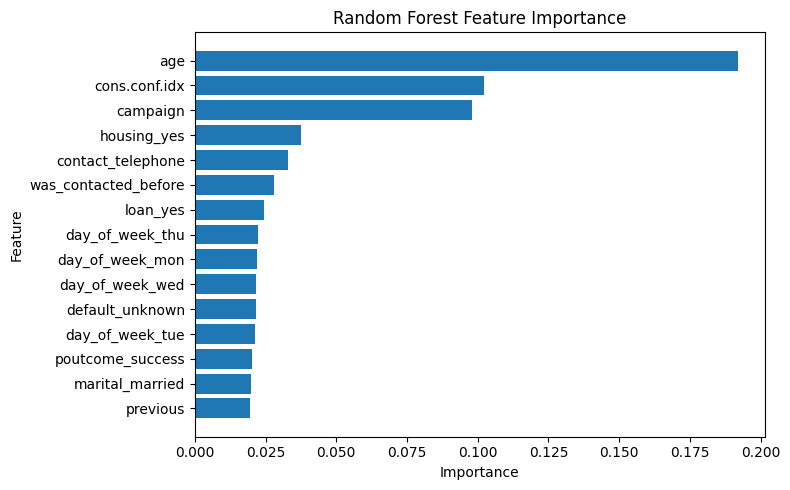

In [ ]:
# Get feature importance
importances = best_rf_classifier.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

# Show top 15 features
print("Top 15 Important Features:")
display(feature_importance.head(15))

# Plot
plt.figure(figsize=(8,5))
plt.barh(
    feature_importance["Feature"].head(15)[::-1],
    feature_importance["Importance"].head(15)[::-1]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Interpretation

* The Random Forest model identifies age as the most influential predictor of term deposit subscription, with a substantially higher importance score than all other variables. This suggests that customer age plays a critical role in distinguishing between subscribers and non-subscribers.

* The second and third most important features are consumer confidence index (cons.conf.idx) and campaign, indicating that both broader economic conditions and the number of contacts made during the campaign significantly influence customer decisions. This highlights that subscription behavior is shaped not only by individual demographics but also by macroeconomic sentiment and marketing intensity.

* Mid-level predictors such as housing loan status, contact type (telephone), and previous contact history further suggest that financial commitments and prior engagement with the bank affect the likelihood of conversion. Customers who were previously contacted or have specific financial obligations appear to respond differently to marketing efforts.

* Lower-ranked variables, including day of the week indicators, marital status, and previous campaign outcome, contribute comparatively less to prediction accuracy. While they provide incremental predictive value, they do not drive the model’s decisions as strongly as demographic and economic variables.

* Overall, the feature importance results indicate that customer demographics and economic context dominate predictive performance, while temporal campaign factors contribute secondary effects. This aligns with marketing theory, where personal characteristics and economic climate often exert stronger influence on financial decision-making than short-term operational factors.




# Limitations

Although the models provide meaningful predictive insights, several limitations should be acknowledged. First, the Random Forest feature importance is based on impurity reduction, which can favor continuous variables such as age, potentially overstating their relative influence. Therefore, the importance rankings reflect model behavior rather than true causal impact.

Second, the dataset is imbalanced, with far more non-subscribers than subscribers. This may bias the models toward predicting the majority class and inflate overall accuracy while reducing sensitivity to potential subscribers.

Additionally, several macroeconomic indicators are likely correlated, which may affect coefficient stability in logistic regression and limit interpretability. The models also treat observations as independent and do not account for potential temporal patterns across different campaign years.

Finally, the analysis is predictive rather than causal. While certain features are associated with subscription likelihood, the models do not establish direct cause-and-effect relationships.

# Future Work

* Future research could improve interpretability by using permutation-based feature importance to reduce bias in importance rankings.

* Addressing class imbalance through techniques such as class weighting or SMOTE could enhance identification of potential subscribers.

* Future work could also explore advanced ensemble methods such as Gradient Boosting, XGBoost, or LightGBM. These algorithms often outperform Random Forest models in structured tabular datasets and may yield improved predictive performance.

* Additionally, incorporating interaction effects or engineered features could better capture complex customer behavior.

* Finally, adopting a cost-sensitive modeling approach that considers marketing expenses and subscription revenue would increase the practical and business relevance of the analysis.